In [18]:
# Data Handling
import pandas as pd
import numpy as np

# NLP
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Save Model
import joblib

In [19]:
import pandas as pd
import numpy as np

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report

nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [20]:
fake = pd.read_csv("fake.csv")
true = pd.read_csv("true.csv")

print(fake.head())
print(true.head())

print(fake.shape)
print(true.shape)

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept t

In [21]:

display(fake.head())
display(true.head())

print(fake.shape)
print(true.shape)

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


(23481, 4)
(21417, 4)


In [22]:
print(fake.duplicated().sum())
print(true.duplicated().sum())

3
206


In [23]:
fake.drop_duplicates(inplace=True)
true.drop_duplicates(inplace=True)
print(fake.duplicated().sum())
print(true.duplicated().sum())

0
0


In [24]:
fake.isnull().sum() 
true.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [25]:
# Add label column to identify fake news as 0
fake["label"] = 0

# Add label column to identify real news as 1
true["label"] = 1

# Combine fake and true news datasets into one dataframe
data = pd.concat([fake, true], axis=0)

# Shuffle the dataset and reset the index
# to mix fake and real news randomly
data = data.sample(frac=1).reset_index(drop=True)

# Display first 5 rows of the final dataset
data.head()

,title,text,subject,date,label
0,'Strong' Franco-British defense relationship w...,PARIS (Reuters) - Britain s exit from the Euro...,worldnews,"August 31, 2017",1
1,BREAKING: Obama Nominates Liberal Merrick Garl...,Obama decides to nominate Merrick Garland for ...,politics,"Mar 16, 2016",0
2,Lawyers Trump Used To ‘Prove’ He Has No Russi...,It was the tweet that blew up the internet:BRE...,News,"May 12, 2017",0
3,European parliament not moving from Strasbourg...,PARIS (Reuters) - France won t let the officia...,worldnews,"December 3, 2017",1
4,CHILLING PHOTO Captures FEMALE SUICIDE BOMBER ...,Why would President Trump want America to enfo...,politics,"Jul 9, 2017",0


In [26]:
data.duplicated().sum()

np.int64(0)

In [27]:
# Drop unnecessary columns
data = data.drop(["subject", "date"], axis=1)

# Display the updated dataset
data.head()

,title,text,label
0,'Strong' Franco-British defense relationship w...,PARIS (Reuters) - Britain s exit from the Euro...,1
1,BREAKING: Obama Nominates Liberal Merrick Garl...,Obama decides to nominate Merrick Garland for ...,0
2,Lawyers Trump Used To ‘Prove’ He Has No Russi...,It was the tweet that blew up the internet:BRE...,0
3,European parliament not moving from Strasbourg...,PARIS (Reuters) - France won t let the officia...,1
4,CHILLING PHOTO Captures FEMALE SUICIDE BOMBER ...,Why would President Trump want America to enfo...,0


In [28]:
# Combine title and article text into one column
data["content"] = data["title"] + " " + data["text"]

# Display the new column
data[["content", "label"]].head()

,content,label
0,'Strong' Franco-British defense relationship w...,1
1,BREAKING: Obama Nominates Liberal Merrick Garl...,0
2,Lawyers Trump Used To ‘Prove’ He Has No Russi...,0
3,European parliament not moving from Strasbourg...,1
4,CHILLING PHOTO Captures FEMALE SUICIDE BOMBER ...,0


In [29]:
data.isnull().sum()

title      0
text       0
label      0
content    0
dtype: int64

In [30]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


# Download NLP resources
nltk.download("stopwords")
nltk.download("wordnet")


# Define stopwords and lemmatizer
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


# Fill missing values
data["content"] = data["content"].fillna("")


# Convert text to string
data["content"] = data["content"].astype(str)


# Convert text to lowercase
data["content"] = data["content"].str.lower()


# Remove special characters and numbers
data["content"] = data["content"].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', x)
)


# Tokenization (split text into words)
data["content"] = data["content"].apply(lambda x: x.split())


# Remove stopwords
data["content"] = data["content"].apply(
    lambda words: [word for word in words if word not in stop_words]
)


# Lemmatization
data["content"] = data["content"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)


# Convert words list back to text
data["clean_content"] = data["content"].apply(
    lambda x: " ".join(x)
)


# Display result
data[["clean_content", "label"]].head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,clean_content,label
0,strong francobritish defense relationship wont...,1
1,breaking obama nominates liberal merrick garla...,0
2,lawyer trump used prove russia connection russ...,0
3,european parliament moving strasbourg france s...,1
4,chilling photo capture female suicide bomber c...,0


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=5000)

# Convert text into vectors
X = vectorizer.fit_transform(data["clean_content"])

# Labels
y = data["label"]

# Check vector shape
print(X.shape)

(44689, 5000)


In [36]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Fit TF-IDF ONLY on training text, then transform both train & test
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_text, X_test_text, y_train, y_test = train_test_split(
    data["clean_content"], y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_text = vectorizer.fit_transform(X_train_text)
X_test_text = vectorizer.transform(X_test_text)

print("Train shape:", X_train_text.shape, " Test shape:", X_test_text.shape)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    data["clean_content"], y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_text = vectorizer.fit_transform(X_train_text)
X_test_text = vectorizer.transform(X_test_text)

X_train, X_test = X_train_text, X_test_text

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

print("Train shape:", X_train_text.shape, " Test shape:", X_test_text.shape)

Train shape: (35751, 5000)  Test shape: (8938, 5000)
Train shape: (35751, 5000)  Test shape: (8938, 5000)
Train shape: (35751, 5000)  Test shape: (8938, 5000)


In [37]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVC": LinearSVC(),
    "Passive Aggressive": PassiveAggressiveClassifier(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    else:
        y_scores = model.decision_function(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_scores),
    })

    fitted_models[name] = (model, y_pred, y_scores)
    print(f"{name} done -> Accuracy: {results[-1]['Accuracy']:.4f}")

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
print("\nModel Comparison:\n", results_df)


c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression done -> Accuracy: 0.9896
Multinomial Naive Bayes done -> Accuracy: 0.9434
Linear SVC done -> Accuracy: 0.9957
Passive Aggressive done -> Accuracy: 0.9956
Random Forest done -> Accuracy: 0.9987

Model Comparison:
                      Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0            Random Forest  0.998657   0.998586  0.998586  0.998586  0.999963
1               Linear SVC  0.995748   0.995054  0.995992  0.995523  0.999771
2       Passive Aggressive  0.995637   0.995754  0.995050  0.995401  0.999693
3      Logistic Regression  0.989595   0.986629  0.991513  0.989065  0.999142
4  Multinomial Naive Bayes  0.943388   0.942654  0.937765  0.940203  0.984690



Best Model: Random Forest
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4696
        Real       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



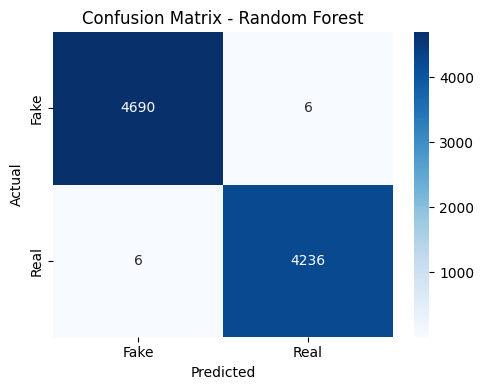

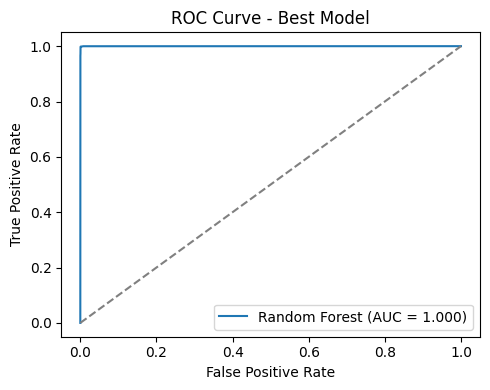

In [38]:
best_model_name = results_df.iloc[0]["Model"]
best_model, best_y_pred, best_y_scores = fitted_models[best_model_name]

print(f"\nBest Model: {best_model_name}")
print(classification_report(y_test, best_y_pred, target_names=["Fake", "Real"]))

# Confusion Matrix
cm = confusion_matrix(y_test, best_y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, best_y_scores)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {results_df.iloc[0]['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best Model")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()


In [39]:
joblib.dump(best_model, "fake_news_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print(f"\nSaved '{best_model_name}' -> fake_news_model.pkl")
print("Saved TF-IDF vectorizer -> tfidf_vectorizer.pkl")


Saved 'Random Forest' -> fake_news_model.pkl
Saved TF-IDF vectorizer -> tfidf_vectorizer.pkl


*NLP*

In [42]:
"""
Fake News Detection - Transformer Fine-tuning (DistilBERT)
=============================================================
Fine-tunes a pretrained DistilBERT model for binary fake/real news
classification.

IMPORTANT - preprocessing is DIFFERENT here than in model_training.py:
We do NOT remove stopwords or lemmatize the text before feeding it to
the transformer. BERT-family models are pretrained on natural language
and rely on full sentence structure / context (and have their own
WordPiece tokenizer), so stripping stopwords or lemmatizing actually
HURTS performance here. We only do light cleanup (missing values,
extra whitespace) and let the tokenizer handle the rest.

Recommended: run this on a GPU runtime (e.g. Google Colab ->
Runtime -> Change runtime type -> GPU/T4). On CPU this will be very
slow (could take hours on the full ~40k-row dataset).
"""

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset

try:
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "transformers"])

from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import sys, subprocess
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import transformers
import sys, subprocess, importlib
import transformers
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
)


MODEL_NAME = "distilbert-base-uncased"   # swap for "bert-base-uncased" for full BERT (slower, slightly heavier)
MAX_LENGTH = 256                         # raise to 512 for longer articles if you have GPU memory to spare
NUM_EPOCHS = 3
BATCH_SIZE = 16


# -----------------------------
# 1) Load & Prepare Data (LIGHT cleaning only - no stopwords/lemmatization)
# -----------------------------
fake = pd.read_csv("fake.csv")
true = pd.read_csv("true.csv")

fake.drop_duplicates(inplace=True)
true.drop_duplicates(inplace=True)

fake["label"] = 0
true["label"] = 1

data = pd.concat([fake, true], axis=0)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

data["title"] = data["title"].fillna("")
data["text"] = data["text"].fillna("")
data["content"] = (data["title"] + " " + data["text"]).apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

print("Dataset shape:", data.shape)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    data["content"], data["label"],
    test_size=0.2, random_state=42, stratify=data["label"]
)


# -----------------------------
# 2) Tokenization
# -----------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize(texts):
    return tokenizer(
        list(texts),
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )


train_encodings = tokenize(X_train_text)
test_encodings = tokenize(X_test_text)


class NewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


train_dataset = NewsDataset(train_encodings, y_train)
test_dataset = NewsDataset(test_encodings, y_test)


# -----------------------------
# 3) Load Pretrained Model
# -----------------------------
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)


# -----------------------------
# 4) Metrics tracked DURING training (each epoch)
# -----------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
    }


# -----------------------------
# 5) Training
# -----------------------------
training_args = TrainingArguments(
    output_dir="./bert_results",
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=2e-5,
    eval_strategy="epoch",      # NOTE: older transformers versions use "evaluation_strategy" instead
    save_strategy="no",
    logging_strategy="epoch",
    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()


# -----------------------------
# 6) Plot Training Curves (loss + validation accuracy per epoch)
# -----------------------------
log_history = trainer.state.log_history
train_loss = [(x["epoch"], x["loss"]) for x in log_history if "loss" in x]
eval_acc = [(x["epoch"], x["eval_accuracy"]) for x in log_history if "eval_accuracy" in x]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(*zip(*train_loss), marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(*zip(*eval_acc), marker="o", color="green")
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)

plt.tight_layout()
plt.savefig("bert_training_curves.png", dpi=150)
plt.show()


# -----------------------------
# 7) Detailed Evaluation on Test Set
# -----------------------------
predictions = trainer.predict(test_dataset)
logits = predictions.predictions
probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
y_pred = np.argmax(logits, axis=1)
y_scores = probs[:, 1]

print(classification_report(y_test, y_pred, target_names=["Fake", "Real"]))
print("ROC-AUC:", roc_auc_score(y_test, y_scores))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.title("Confusion Matrix - DistilBERT")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("bert_confusion_matrix.png", dpi=150)
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_scores)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"DistilBERT (AUC = {roc_auc_score(y_test, y_scores):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DistilBERT")
plt.legend()
plt.tight_layout()
plt.savefig("bert_roc_curve.png", dpi=150)
plt.show()


# -----------------------------
# 8) Save Fine-tuned Model + Tokenizer (for FastAPI / Streamlit)
# -----------------------------
model.save_pretrained("distilbert_fake_news_model")
tokenizer.save_pretrained("distilbert_fake_news_model")
print("Saved fine-tuned model -> ./distilbert_fake_news_model")


IndentationError: expected an indented block after 'try' statement on line 29 (3345697699.py, line 30)